In [13]:
import pandas as pd
likelihood = pd.read_csv("../data/likelihood_data.csv")

X,y = likelihood["X"].values, likelihood["y"].values

In [14]:
import numpy as np
beta_values = np.linspace(-1, 2, 100)
beta_values


array([-1.        , -0.96969697, -0.93939394, -0.90909091, -0.87878788,
       -0.84848485, -0.81818182, -0.78787879, -0.75757576, -0.72727273,
       -0.6969697 , -0.66666667, -0.63636364, -0.60606061, -0.57575758,
       -0.54545455, -0.51515152, -0.48484848, -0.45454545, -0.42424242,
       -0.39393939, -0.36363636, -0.33333333, -0.3030303 , -0.27272727,
       -0.24242424, -0.21212121, -0.18181818, -0.15151515, -0.12121212,
       -0.09090909, -0.06060606, -0.03030303,  0.        ,  0.03030303,
        0.06060606,  0.09090909,  0.12121212,  0.15151515,  0.18181818,
        0.21212121,  0.24242424,  0.27272727,  0.3030303 ,  0.33333333,
        0.36363636,  0.39393939,  0.42424242,  0.45454545,  0.48484848,
        0.51515152,  0.54545455,  0.57575758,  0.60606061,  0.63636364,
        0.66666667,  0.6969697 ,  0.72727273,  0.75757576,  0.78787879,
        0.81818182,  0.84848485,  0.87878788,  0.90909091,  0.93939394,
        0.96969697,  1.        ,  1.03030303,  1.06060606,  1.09

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

likelihoods = []
for beta in beta_values:
    theta = sigmoid(beta * X)
    individual_likelihoods = (theta**y) * ((1 - theta) ** (1 - y))
    L = np.prod(individual_likelihoods)
    likelihoods.append(L)

likelihoods = np.array(likelihoods)

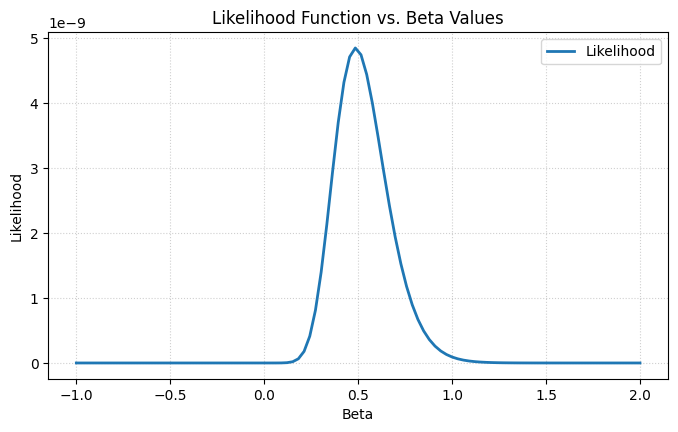

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.plot(beta_values, likelihoods, label="Likelihood", color="tab:blue", lw=2)
plt.title("Likelihood Function vs. Beta Values")
plt.xlabel("Beta")
plt.ylabel("Likelihood")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

Observation: The peak is just below 0.5

In [ ]:
max_idx = np.argmax(likelihoods)
best_beta_manual = beta_values[max_idx]
print(f"Optimal Beta (Grid Search): {best_beta_manual:.4f}")


Optimal Beta (Grid Search): 0.4848


Logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X.reshape(-1, 1), y)
sklearn_beta = model.coef_[0][0]
print(f"Sklearn Coefficient (Beta): {sklearn_beta:.4f}")

Sklearn Coefficient (Beta): 0.4935


Observation: Beta coefficient for logistic regression is similar yet slightly above my manual likelihood calculation